In [1]:
import tensorflow as tf

print("Versi TensorFlow:", tf.__version__)

# Perintah ini adalah kuncinya:
gpu_list = tf.config.list_physical_devices('GPU')

if not gpu_list:
    print("=" * 40)
    print("!!! GAGAL !!!")
    print("TensorFlow TIDAK dapat menemukan GPU Anda.")
    print("Pastikan Driver NVIDIA sudah terinstal dan coba restart.")
    print("=" * 40)
else:
    print("=" * 40)
    print("✨ BERHASIL! ✨")
    print("TensorFlow berhasil mendeteksi GPU Anda:")
    for gpu in gpu_list:
        print(f"- {gpu.name}")
    print("=" * 40)

# Anda juga bisa menjalankan tes kecil
print("\nMenjalankan operasi tes kecil di GPU...")
try:
    with tf.device('/GPU:0'):
        a = tf.constant([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]])
        b = tf.constant([[1.0, 2.0], [3.0, 4.0], [5.0, 6.0]])
        c = tf.matmul(a, b)
    print("Operasi tes berhasil dijalankan di GPU.")
    print("Hasil (dari GPU):")
    print(c.numpy())
except RuntimeError as e:
    print("Operasi tes GAGAL:", e)

Versi TensorFlow: 2.20.0
!!! GAGAL !!!
TensorFlow TIDAK dapat menemukan GPU Anda.
Pastikan Driver NVIDIA sudah terinstal dan coba restart.

Menjalankan operasi tes kecil di GPU...
Operasi tes berhasil dijalankan di GPU.
Hasil (dari GPU):
[[22. 28.]
 [49. 64.]]


In [3]:
import pandas as pd
import os
import numpy as np

# --- 1. Konfigurasi Path ---
# Sesuaikan dengan path Anda
AUDIO_DIR = r"C:\Users\Auron\Documents\GAN_Music\MEMD_audio"
ANNOTATION_DIR = r"C:\Users\Auron\Documents\GAN_Music\annotations\annotations averaged per song\dynamic (per second annotations)"

VALENCE_FILE = os.path.join(ANNOTATION_DIR, "valence.csv")
AROUSAL_FILE = os.path.join(ANNOTATION_DIR, "arousal.csv")

print("Memulai Verifikasi Dataset...\n")

# --- 2. Verifikasi File Anotasi (Pandas) ---
print("--- 1. Mengecek File Anotasi (Pandas) ---")
val_df = None
aro_df = None
try:
    # Kita muat 5 baris pertama saja (head(5)) untuk tes
    val_df = pd.read_csv(VALENCE_FILE, index_col=0, sep=',', nrows=5)
    aro_df = pd.read_csv(AROUSAL_FILE, index_col=0, sep=',', nrows=5)
    
    print(f"✅ BERHASIL memuat: {VALENCE_FILE}")
    print(f"✅ BERHASIL memuat: {AROUSAL_FILE}")
    
    # Tampilkan 5 baris pertama untuk Anda lihat
    print("\nContoh 5 baris pertama data Valence:")
    print(val_df.head())
    print("\nContoh 5 baris pertama data Arousal:")
    print(aro_df.head())
    
except Exception as e:
    print(f"❌ GAGAL memuat file CSV: {e}")
    print("   Pastikan path benar dan pemisah (sep=',') sudah sesuai.")
    print("   Coba ganti sep=',' menjadi sep='\\t' jika masih gagal.")

# --- 3. Verifikasi File Audio (OS) ---
print("\n--- 2. Mengecek File Audio (OS) ---")
mp3_files = []
try:
    audio_files = os.listdir(AUDIO_DIR)
    mp3_files = [f for f in audio_files if f.endswith('.mp3')]
    
    if not mp3_files:
        print(f"❌ PERINGATAN: Tidak ada file .mp3 yang ditemukan di:")
        print(f"   {AUDIO_DIR}")
    else:
        print(f"✅ BERHASIL: Total {len(mp3_files)} file .mp3 ditemukan.")
        print(f"   Contoh file: {mp3_files[0]}")
        
except Exception as e:
    print(f"❌ GAGAL mengakses folder audio: {e}")
    print(f"   Pastikan path ini benar: {AUDIO_DIR}")

# --- 4. Verifikasi Sinkronisasi (Cross-Check) ---
# Ini adalah bagian terpenting
print("\n--- 3. Mengecek Sinkronisasi (Paling Penting) ---")
if (val_df is not None) and (aro_df is not None) and mp3_files:
    # Muat semua ID (bukan hanya 5 baris) untuk perbandingan
    val_ids = set(pd.read_csv(VALENCE_FILE, index_col=0, sep=',').index.astype(str))
    aro_ids = set(pd.read_csv(AROUSAL_FILE, index_col=0, sep=',').index.astype(str))
    
    print(f"Total ID lagu unik di 'valence.csv': {len(val_ids)}")
    print(f"Total ID lagu unik di 'arousal.csv': {len(aro_ids)}")
    
    # Cek jika file valence dan arousal cocok
    if val_ids != aro_ids:
        print("❌ PERINGATAN: Daftar ID lagu di 'valence.csv' dan 'arousal.csv' TIDAK SAMA!")
    else:
        print("✅ OK: Daftar ID lagu di kedua file anotasi SAMA.")

    # Ekstrak ID dari nama file audio
    audio_ids = set([f.split('.')[0] for f in mp3_files])
    print(f"Total file .mp3 (ID unik): {len(audio_ids)}")
    
    # Bandingkan anotasi dengan audio
    annotation_ids = val_ids # Kita asumsikan keduanya sama
    
    # Anotasi yang tidak punya file audio
    anotasi_tanpa_audio = annotation_ids - audio_ids
    if anotasi_tanpa_audio:
        print(f"❌ PERINGATAN: Ada {len(anotasi_tanpa_audio)} ID di file anotasi yang tidak memiliki file .mp3.")
    else:
        print("✅ OK: Semua ID di file anotasi memiliki file .mp3 yang cocok.")
        
    # File audio yang tidak punya anotasi
    audio_tanpa_anotasi = audio_ids - annotation_ids
    if audio_tanpa_anotasi:
        print(f"❌ PERINGATAN: Ada {len(audio_tanpa_anotasi)} file .mp3 yang tidak memiliki ID di file anotasi.")
    else:
        print("✅ OK: Semua file .mp3 memiliki anotasi yang cocok.")
        
    # --- Kesimpulan ---
    jumlah_cocok = len(annotation_ids.intersection(audio_ids))
    print("\n--- KESIMPULAN VERIFIKASI ---")
    print(f"Anda memiliki {jumlah_cocok} lagu yang datanya LENGKAP (memiliki file audio DAN anotasi).")
    
    if jumlah_cocok > 0:
        print("👍 Anda SIAP untuk menjalankan script preprocessing Fase 1.")
    else:
        print("👎 GAGAL. Harap periksa path dan isi folder Anda sebelum melanjutkan.")
else:
    print("\n--- KESIMPULAN VERIFIKASI ---")
    print("👎 GAGAL. Verifikasi tidak dapat dilanjutkan karena file anotasi atau audio tidak ditemukan.")

Memulai Verifikasi Dataset...

--- 1. Mengecek File Anotasi (Pandas) ---
✅ BERHASIL memuat: C:\Users\Auron\Documents\GAN_Music\annotations\annotations averaged per song\dynamic (per second annotations)\valence.csv
✅ BERHASIL memuat: C:\Users\Auron\Documents\GAN_Music\annotations\annotations averaged per song\dynamic (per second annotations)\arousal.csv

Contoh 5 baris pertama data Valence:
         sample_15000ms  sample_15500ms  sample_16000ms  sample_16500ms  \
song_id                                                                   
2             -0.073341       -0.074661       -0.074077       -0.078154   
3             -0.189702       -0.187765       -0.183740       -0.188761   
4              0.154286        0.148063        0.146956        0.151180   
5              0.149053        0.148260        0.147369        0.146956   
7              0.342816        0.345193        0.332023        0.328887   

         sample_17000ms  sample_17500ms  sample_18000ms  sample_18500ms  \
song_i

In [1]:
import pandas as pd
import librosa
import numpy as np
import os
from tqdm import tqdm # Library untuk menampilkan progress bar
import warnings
import re # Library untuk parsing teks

# --- 1. Konfigurasi Utama (Telah disesuaikan) ---

SAMPLE_RATE = 16000
SEGMENT_SEC = 2
SEGMENT_LENGTH = SAMPLE_RATE * SEGMENT_SEC # 32000 sampel

# Path ke folder data Anda
AUDIO_DIR = r"C:\Users\Auron\Documents\GAN_Music\MEMD_audio"
ANNOTATION_DIR = r"C:\Users\Auron\Documents\GAN_Music\annotations\annotations averaged per song\dynamic (per second annotations)"
OUTPUT_DIR = r"./processed_data/"

# Path lengkap ke file anotasi
VALENCE_FILE = os.path.join(ANNOTATION_DIR, "valence.csv")
AROUSAL_FILE = os.path.join(ANNOTATION_DIR, "arousal.csv")

# --- 2. Inisialisasi ---
os.makedirs(OUTPUT_DIR, exist_ok=True)
all_audio_segments = []
all_emotion_labels = []
warnings.filterwarnings('ignore', category=UserWarning, module='librosa')

print("Memulai pemrosesan dataset (Metode 5: Penanganan 'sample_...ms')...")

# --- 3. Muat File Anotasi (Satu Kali) ---
# Menggunakan sep=',' berdasarkan hasil verifikasi Anda
try:
    print("Memuat valence.csv...")
    valence_df = pd.read_csv(VALENCE_FILE, index_col=0, sep=',') 
    print("Memuat arousal.csv...")
    arousal_df = pd.read_csv(AROUSAL_FILE, index_col=0, sep=',')
except Exception as e:
    print(f"ERROR: Gagal memuat file CSV: {e}")
    exit()

# --- 4. BARU: Fungsi Pembersihan Kolom yang Diperbaiki ---
print("Membersihkan kolom anotasi (mengkonversi 'sample_...ms' ke detik)...")

def clean_and_convert_columns(df):
    """
    Fungsi ini mengambil DataFrame, membersihkan nama kolom,
    dan mengkonversi nama kolom ke float (detik).
    """
    new_columns = {} # Dictionary untuk menyimpan {nama_lama: nama_baru}
    valid_cols = []  # List untuk menyimpan nama kolom yang valid
    
    for col_name in df.columns:
        # Coba ekstrak angka dari string seperti 'sample_15000ms'
        match = re.search(r'sample_(\d+)ms', str(col_name))
        
        if match:
            # Jika cocok (ditemukan angka)
            milliseconds = int(match.group(1))
            seconds = milliseconds / 1000.0 # Konversi ke detik
            new_columns[col_name] = seconds # Simpan mapping nama
            valid_cols.append(col_name)     # Tandai sebagai kolom valid
        else:
            # Jika nama kolom bukan format 'sample_...ms', abaikan
            continue
            
    # Ambil hanya kolom yang valid
    cleaned_df = df[valid_cols]
    
    # Ganti nama kolom dari 'sample_15000ms' menjadi 15.0
    cleaned_df = cleaned_df.rename(columns=new_columns)
    
    return cleaned_df

# Bersihkan kedua DataFrame
valence_df_clean = clean_and_convert_columns(valence_df)
arousal_df_clean = clean_and_convert_columns(arousal_df)

if valence_df_clean.empty or arousal_df_clean.empty:
    print("="*50)
    print("ERROR FATAL: Tidak ada kolom timestamp yang valid ditemukan.")
    print("Format nama kolom mungkin berbeda dari 'sample_...ms'.")
    print("="*50)
    exit()

print(f"Pembersihan kolom selesai. Ditemukan {len(valence_df_clean.columns)} kolom timestamp valid.")

# Konversi index (song_id) menjadi string agar mudah dicocokkan
valence_df_clean.index = valence_df_clean.index.astype(str)
arousal_df_clean.index = arousal_df_clean.index.astype(str)

# --- 5. Iterasi File Audio dan Proses ---
audio_files = os.listdir(AUDIO_DIR)

for audio_file in tqdm(audio_files, desc="Memproses lagu"):
    if not audio_file.endswith('.mp3'):
        continue
        
    song_id = audio_file.split('.')[0]
    audio_file_path = os.path.join(AUDIO_DIR, audio_file)
    
    # --- 5a. Cek Ketersediaan Label ---
    if song_id not in valence_df_clean.index or song_id not in arousal_df_clean.index:
        continue
        
    val_series = valence_df_clean.loc[song_id]
    aro_series = arousal_df_clean.loc[song_id]

    # --- 5b. Muat Audio ---
    try:
        waveform, sr = librosa.load(audio_file_path, sr=SAMPLE_RATE, mono=True)
    except Exception as e:
        continue

    # --- 5c. Potong Audio & Rata-ratakan Label ---
    num_segments = len(waveform) // SEGMENT_LENGTH
    
    for i in range(num_segments):
        start_sample = i * SEGMENT_LENGTH
        end_sample = start_sample + SEGMENT_LENGTH
        audio_segment = waveform[start_sample:end_sample]
        
        start_time_sec = i * SEGMENT_SEC
        end_time_sec = (i + 1) * SEGMENT_SEC
        
        # Ambil nama kolom (timestamp) yang relevan
        # Sekarang nama kolomnya sudah float (detik)
        relevant_cols_val = val_series.index[
            (val_series.index >= start_time_sec) & 
            (val_series.index < end_time_sec)
        ]
        relevant_cols_aro = aro_series.index[
            (aro_series.index >= start_time_sec) & 
            (aro_series.index < end_time_sec)
        ]
        
        if relevant_cols_val.empty or relevant_cols_aro.empty:
            continue 
            
        # Hitung rata-rata V-A untuk segmen ini
        avg_valence = val_series[relevant_cols_val].mean()
        avg_arousal = aro_series[relevant_cols_aro].mean()
        
        # --- 5d. Kumpulkan Hasil ---
        all_audio_segments.append(audio_segment)
        all_emotion_labels.append([avg_valence, avg_arousal])

# --- 6. Konversi Final dan Penyimpanan ---

print(f"\nSelesai memproses! Total segmen yang valid: {len(all_audio_segments)}")

if len(all_audio_segments) == 0:
    print("\nPERINGATAN: Total segmen 0. Periksa kembali kecocokan ID lagu.")
else:
    # Ubah list menjadi array NumPy
    X_train = np.array(all_audio_segments)
    y_train = np.array(all_emotion_labels)

    # Tambahkan satu dimensi 'channel' di akhir (format untuk Conv1D)
    if len(X_train.shape) == 2:
        X_train = np.expand_dims(X_train, axis=-1)

    print(f"Shape X_train final (data audio): {X_train.shape}")
    print(f"Shape y_train final (data label): {y_train.shape}")

    # Simpan ke file .npy
    output_path_x = os.path.join(OUTPUT_DIR, "X_train_deam.npy")
    output_path_y = os.path.join(OUTPUT_DIR, "y_train_deam.npy")

    np.save(output_path_x, X_train)
    np.save(output_path_y, y_train)

    print(f"\nDataset berhasil disimpan di:")
    print(f"Data Audio: {output_path_x}")
    print(f"Data Label: {output_path_y}")

Memulai pemrosesan dataset (Metode 5: Penanganan 'sample_...ms')...
Memuat valence.csv...
Memuat arousal.csv...
Membersihkan kolom anotasi (mengkonversi 'sample_...ms' ke detik)...
Pembersihan kolom selesai. Ditemukan 1223 kolom timestamp valid.


Memproses lagu: 100%|██████████████████████████████████████████████████████████████| 1802/1802 [02:34<00:00, 11.65it/s]



Selesai memproses! Total segmen yang valid: 32509
Shape X_train final (data audio): (32509, 32000, 1)
Shape y_train final (data label): (32509, 2)

Dataset berhasil disimpan di:
Data Audio: ./processed_data/X_train_deam.npy
Data Label: ./processed_data/y_train_deam.npy


Memulai Validasi Dataset...

✅ Berhasil memuat data:
   X_data shape: (32509, 32000, 1)
   y_data shape: (32509, 2)

--- 1. Pengecekan Teknis ---
✅ [OK] Jumlah sampel cocok: 32509 audio & 32509 label.
✅ [OK] Data audio (X_data) bersih dari NaN/Infinity.
✅ [OK] Data label (y_data) bersih dari NaN/Infinity.

--- 2. Pengecekan Statistik ---
Audio (X_data) Range: Min=-1.5366, Max=1.3633
   ⚠️ [PERINGATAN] Rentang audio di luar [-1.0, 1.0]. Mungkin perlu normalisasi?

Statistik Label Emosi (y_data):
            Valence       Arousal
count  32509.000000  32509.000000
mean       0.077235      0.126919
std        0.249993      0.281682
min       -0.831000     -0.763009
25%       -0.094000     -0.082670
50%        0.095000      0.132500
75%        0.268500      0.352750
max        0.711500      0.896000

--- 3. Pengecekan Kualitatif (Mendengarkan Sampel) ---
Anda akan mendengarkan 4 sampel audio ekstrem.
Pastikan headphone Anda terpasang!

Memutar sampel untuk: SENANG / GEMBIRA (V tinggi, A tin

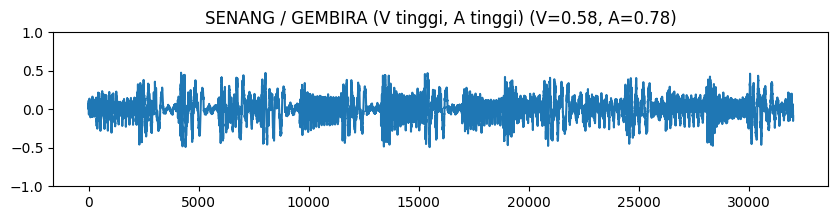

Memutar audio... (Tekan Ctrl+C di terminal/Stop di Jupyter untuk berhenti)

Memutar sampel untuk: SEDIH / BOSAN (V rendah, A rendah)
Index: 28533
Label (V, A): (-0.5511, -0.6764)


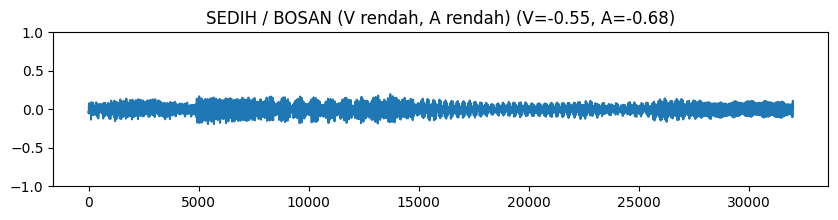

Memutar audio... (Tekan Ctrl+C di terminal/Stop di Jupyter untuk berhenti)

Memutar sampel untuk: MARAH / TEGANG (V rendah, A tinggi)
Index: 16659
Label (V, A): (-0.7460, 0.8870)


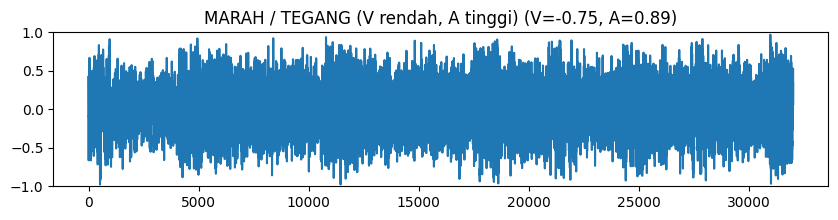

Memutar audio... (Tekan Ctrl+C di terminal/Stop di Jupyter untuk berhenti)

Memutar sampel untuk: TENANG / DAMAI (V tinggi, A rendah)
Index: 19500
Label (V, A): (0.4240, -0.2965)


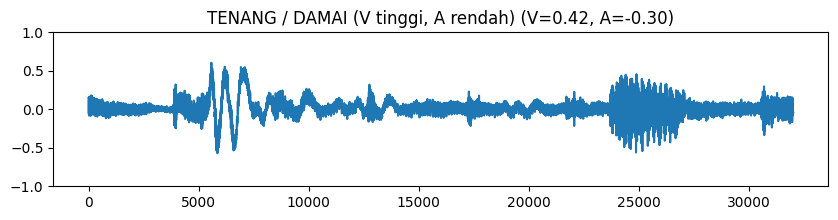

Memutar audio... (Tekan Ctrl+C di terminal/Stop di Jupyter untuk berhenti)

--- KESIMPULAN VALIDASI ---
✅ Validasi selesai.
TUGAS ANDA: Apakah audio yang Anda dengar SESUAI dengan deskripsi emosinya?
Jika ya, Anda SIAP untuk Fase 2 (Pelatihan Model).
Jika tidak (misal: 'SENANG' terdengar sedih), ada masalah di Fase 1.


In [2]:
# Verifikasi Dataset 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sounddevice as sd
import os

# --- 1. Konfigurasi (Sesuaikan jika perlu) ---
OUTPUT_DIR = r"./processed_data/"
X_TRAIN_FILE = os.path.join(OUTPUT_DIR, "X_train_deam.npy")
Y_TRAIN_FILE = os.path.join(OUTPUT_DIR, "y_train_deam.npy")

# SAMAKAN DENGAN FASE 1
SAMPLE_RATE = 16000 

print("Memulai Validasi Dataset...\n")

# --- 2. Muat Dataset yang Telah Diproses ---
try:
    X_data = np.load(X_TRAIN_FILE)
    y_data = np.load(Y_TRAIN_FILE)
    print(f"✅ Berhasil memuat data:")
    print(f"   X_data shape: {X_data.shape}")
    print(f"   y_data shape: {y_data.shape}")
except FileNotFoundError:
    print(f"❌ GAGAL: File .npy tidak ditemukan di {OUTPUT_DIR}")
    print("   Pastikan Anda sudah menjalankan script Fase 1 terlebih dahulu.")
    exit()

# --- 3. Pengecekan Teknis (Kuantitatif) ---
print("\n--- 1. Pengecekan Teknis ---")

# Cek 1: Kesesuaian Jumlah Sampel
if X_data.shape[0] == y_data.shape[0]:
    print(f"✅ [OK] Jumlah sampel cocok: {X_data.shape[0]} audio & {y_data.shape[0]} label.")
    total_samples = X_data.shape[0]
else:
    print(f"❌ [ERROR] Jumlah sampel TIDAK COCOK: {X_data.shape[0]} audio vs {y_data.shape[0]} label.")
    exit()

# Cek 2: Cek nilai NaN (Not a Number) atau Infinity
if np.isnan(X_data).any() or np.isinf(X_data).any():
    print("❌ [ERROR] Data audio (X_data) mengandung nilai NaN atau Infinity!")
else:
    print("✅ [OK] Data audio (X_data) bersih dari NaN/Infinity.")

if np.isnan(y_data).any() or np.isinf(y_data).any():
    print("❌ [ERROR] Data label (y_data) mengandung nilai NaN atau Infinity!")
else:
    print("✅ [OK] Data label (y_data) bersih dari NaN/Infinity.")

# --- 4. Pengecekan Statistik (Kuantitatif) ---
print("\n--- 2. Pengecekan Statistik ---")

# Cek rentang nilai audio (waveform harus antara -1.0 dan 1.0)
min_audio, max_audio = X_data.min(), X_data.max()
print(f"Audio (X_data) Range: Min={min_audio:.4f}, Max={max_audio:.4f}")
if min_audio < -1.0 or max_audio > 1.0:
    print("   ⚠️ [PERINGATAN] Rentang audio di luar [-1.0, 1.0]. Mungkin perlu normalisasi?")
else:
    print("   ✅ [OK] Rentang audio berada dalam [-1.0, 1.0].")

# Cek statistik label V-A (Valence-Arousal)
# Gunakan pandas untuk deskripsi statistik yang mudah dibaca
label_df = pd.DataFrame(y_data, columns=['Valence', 'Arousal'])
print("\nStatistik Label Emosi (y_data):")
print(label_df.describe())

# --- 5. Pengecekan Kualitatif (Sanity Check) ---
print("\n--- 3. Pengecekan Kualitatif (Mendengarkan Sampel) ---")
print("Anda akan mendengarkan 4 sampel audio ekstrem.")
print("Pastikan headphone Anda terpasang!")

# Buat fungsi untuk memutar audio
def play_sample(index, description):
    print(f"\nMemutar sampel untuk: {description}")
    print(f"Index: {index}")
    label = y_data[index]
    audio = X_data[index]
    print(f"Label (V, A): ({label[0]:.4f}, {label[1]:.4f})")
    
    # Visualisasi waveform (opsional tapi bagus)
    plt.figure(figsize=(10, 2))
    plt.plot(audio)
    plt.title(f"{description} (V={label[0]:.2f}, A={label[1]:.2f})")
    plt.ylim(-1, 1)
    plt.show()
    
    # Putar audio
    print("Memutar audio... (Tekan Ctrl+C di terminal/Stop di Jupyter untuk berhenti)")
    try:
        sd.play(audio.flatten(), SAMPLE_RATE)
        sd.wait() # Tunggu sampai audio selesai
    except KeyboardInterrupt:
        sd.stop()
    except Exception as e:
        print(f"Gagal memutar audio: {e}")

# Cari index dari sampel-sampel ekstrem
# (V=Positif, A=Positif) -> Senang / Gembira
idx_happy = np.argmax(y_data.sum(axis=1)) # Menjumlahkan V+A

# (V=Negatif, A=Negatif) -> Sedih / Bosan
idx_sad = np.argmin(y_data.sum(axis=1)) # Min V+A

# (V=Negatif, A=Positif) -> Marah / Tegang
idx_angry = np.argmax(y_data[:, 1] - y_data[:, 0]) # Max (A - V)

# (V=Positif, A=Negatif) -> Tenang / Damai
idx_calm = np.argmax(y_data[:, 0] - y_data[:, 1]) # Max (V - A)

# Putar sampelnya
try:
    play_sample(idx_happy, "SENANG / GEMBIRA (V tinggi, A tinggi)")
    play_sample(idx_sad, "SEDIH / BOSAN (V rendah, A rendah)")
    play_sample(idx_angry, "MARAH / TEGANG (V rendah, A tinggi)")
    play_sample(idx_calm, "TENANG / DAMAI (V tinggi, A rendah)")
    
    print("\n--- KESIMPULAN VALIDASI ---")
    print("✅ Validasi selesai.")
    print("TUGAS ANDA: Apakah audio yang Anda dengar SESUAI dengan deskripsi emosinya?")
    print("Jika ya, Anda SIAP untuk Fase 2 (Pelatihan Model).")
    print("Jika tidak (misal: 'SENANG' terdengar sedih), ada masalah di Fase 1.")
    
except Exception as e:
    print(f"\nTerjadi error saat memutar audio: {e}")
    sd.stop()